<h2 style="font-weight:600;color:#7fba94">Clustering - Introduction</h2>

In contrast to *supervised* machine learning, *unsupervised* learning is used when there is no "ground truth" from which to train and validate label predictions. The most common form of unsupervised learning is *clustering*, which is similar conceptually to *classification*, except that the the training data does not include known values for the class label to be predicted. Clustering works by separating the training cases based on similarities that can be determined from their feature values. The numeric features of a given entity can be thought of as vector coordinates that define the entity's position in n-dimensional space. What a clustering model seeks to do is to identify groups, or *clusters*, of entities that are close to one another while being separated from other clusters.

For example, let's take a look at a dataset that contains measurements of different species of wheat seed.



<h3 style="font-weight:600;color:white;background:#7fba94;padding:25px;margin:20;text-align:left;display:fill;border-radius:10px 0 0 10px;text-transform:uppercase;">1 | Load the Data</h3>

> **Citation**: The seeds dataset used in this exercise was originally published by the Institute of Agrophysics of the Polish Academy of Sciences in Lublin by Dua, D. and Graff, C. (2019). and can be downloaded from the [UCI Machine Learning Repository](http://archive.ics.uci.edu/ml), University of California at Irvine, School of Information and Computer Science.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# load the training dataset
data = pd.read_csv("seeds.csv")

# Display a random sample of 10 observations (just the features)
features = data[data.columns[0:6]]
features.sample(10)

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient
176,11.26,13.01,0.8355,5.186,2.710,5.335
144,11.82,13.40,0.8274,5.314,2.777,4.471
58,15.38,14.77,0.8857,5.662,3.419,1.999
85,18.27,16.09,0.8870,6.173,3.651,2.443
130,18.30,15.89,0.9108,5.979,3.755,2.837
67,14.01,14.29,0.8625,5.609,3.158,2.217
194,12.11,13.27,0.8639,5.236,2.975,4.132
169,11.24,13.00,0.8359,5.090,2.715,3.521
106,18.85,16.17,0.9056,6.152,3.806,2.843
43,15.50,14.86,0.8820,5.877,3.396,4.711


As you can see, the dataset contains six data points (or *features*) for each instance (*observation*) of a seed. So you could interpret these as coordinates that describe each instance's location in six-dimensional space.

Six-dimensional space is difficult to visualize in a three-dimensional world, or on a two-dimensional plot. We'll take advantage of a mathematical technique called *Principal Component Analysis* (PCA) to analyze the relationships between the features and summarize each observation as coordinates for two principal components - in other words, we'll <span style="font-weight:600;color:#7fba94;text-decoration:underline;">translate the six-dimensional feature values into two-dimensional coordinates</span>.

In [2]:
# Normalize the numeric features so they're on the same scale
scaled_features = MinMaxScaler().fit_transform(features)

# Get two principal components
pca = PCA(n_components=2).fit(scaled_features)

# Apply dimensionality reduction to the DataFrame
features_2d = pca.transform(scaled_features)

print(features_2d[0:10])

[[ 0.11883593 -0.09382469]
 [ 0.0696878  -0.31077233]
 [-0.03499184 -0.37044705]
 [-0.06582089 -0.36365235]
 [ 0.32594892 -0.37695797]
 [-0.02455447 -0.31060184]
 [-0.00769646 -0.07594931]
 [-0.05646955 -0.26696284]
 [ 0.38196305 -0.05149471]
 [ 0.35701044 -0.17697998]]


Now that we have the data points translated to two dimensions, we can visualize them in a plot.

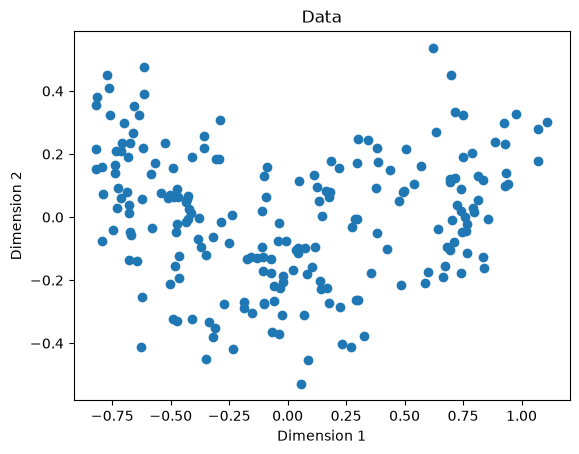

In [3]:
plt.scatter(features_2d[:, 0], features_2d[:, 1])
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("Data")

plt.show()

Hopefully you can see at least two, arguably three, reasonably distinct groups of data points. This shows one of the fundamental problems with clustering - without known class labels, how do you know how many clusters to separate your data into?

One way we can try to find out is to use a data sample to create a series of clustering models with an incrementing number of clusters, and measure how tightly the data points are grouped within each cluster. A metric often used to measure this tightness is the <span style="font-weight:600;color:#7fba94;text-decoration:underline;">within cluster sum of squares (WCSS)</span>, with lower values meaning that the data points are closer. You can then plot the WCSS for each model.

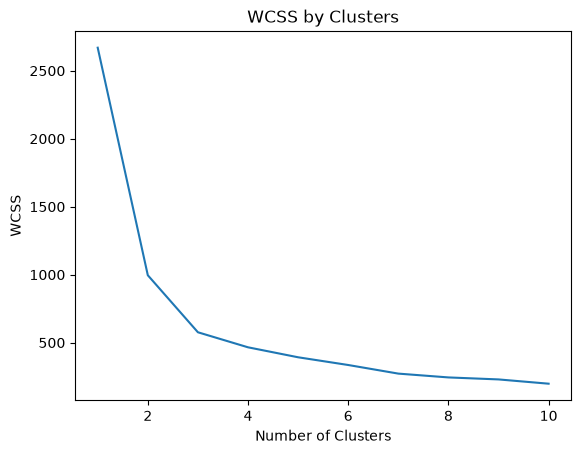

In [4]:
# Create 10 models with 1 to 10 clusters.
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i)
    # Fit the data points
    kmeans.fit(features.values)
    # Get the WCSS (inertia) value
    wcss.append(kmeans.inertia_)

# Plot the WCSS values into a line graph.
plt.plot(range(1, 11), wcss)
plt.title("WCSS by Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

The plot shows a large reduction in WCSS (so greater *tightness*) as the number of clusters increases <span style="font-weight:600;color:#7fba94;text-decoration:underline;">from one to two, and a further noticable reduction from two to three clusters</span>. After that, the reduction is less pronounced, resulting in an "elbow" in the chart at around three clusters. This is a good indication that there are two to three reasonably well separated clusters of data points.

<h3 style="font-weight:600;color:white;background:#7fba94;padding:25px;margin:20;text-align:left;display:fill;border-radius:10px 0 0 10px;text-transform:uppercase;">2 | Summary</h3>

Here we looked at what clustering means, and how to determine whether clustering might be appropriate for your data. In the next notebook, we will look at two ways of 
labelling the data automatically.

<h3 style="font-weight:600;color:white;background:#7fba94;padding:25px;margin:20;text-align:left;display:fill;border-radius:10px 0 0 10px;text-transform:uppercase;">3 | K-Means Clustering</h3>

The algorithm we'll use to create our test clusters is *K-Means*. This is a commonly used clustering algorithm that separates a dataset into *K* clusters of equal variance. The number of clusters, *K*, is user-defined. The algorithm has the following steps:

1. A set of K centroids are randomly chosen.
2. Clusters are formed by assigning the data points to their closest centroid.
3. The mean of each cluster is computed and the centroid is moved to the mean.
4. Steps 2 and 3 are repeated until a stopping criteria is met. Typically, the algorithm terminates when each new iteration results in negligible movement of centroids and the clusters become static.
5. When the clusters stop changing, the algorithm has *converged*, defining the locations of the clusters. Note that the random starting point for the centroids means that re-running the algorithm could result in slightly different clusters, so training usually involves multiple iterations, re-initializing the centroids each time, and the model with the best WCSS (*within cluster sum of squares*) is selected.

Let's try using K-Means on our seeds data with a K value of 3.

In [5]:
# Create a model based on 3 centroids
# init  :   method for initialization.
#           k-means++ selects initial cluster centroids using sampling
#           based on an empirical probability distribution of the points'
#           contribution to the overall inertia.
# n_init:   number of times the algorithm is run with different centroids.
# max_iter: max number of iterations of the algorithm.
model = KMeans(n_clusters=3, init="k-means++", n_init=100, max_iter=1000)

# Fit to the data and predict the cluster assignments for each data point.
km_clusters = model.fit_predict(features.values)

# View the cluster assignments
print(km_clusters)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 2 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0
 1 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 2 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2]


Now, let's see those cluster assignments with the two-dimensional data points.

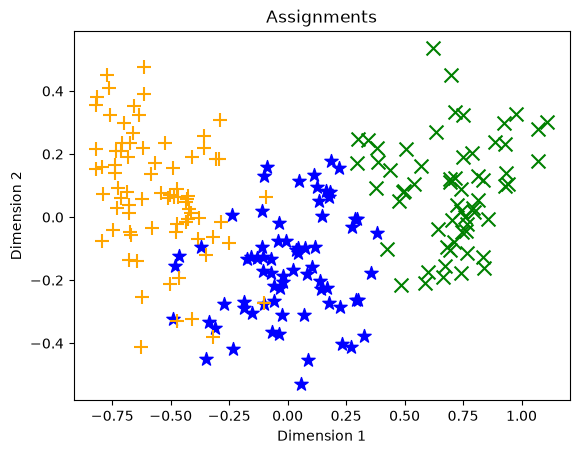

In [6]:
def plot_clusters(samples, clusters):
    col_dic = {0: "blue", 1: "green", 2: "orange"}
    mrk_dic = {0: "*", 1: "x", 2: "+"}
    colors = [col_dic[x] for x in clusters]
    markers = [mrk_dic[x] for x in clusters]

    for sample in range(len(clusters)):
        plt.scatter(samples[sample][0], samples[sample][1], color=colors[sample], marker=markers[sample], s=100)

    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.title("Assignments")
    plt.show()


plot_clusters(features_2d, km_clusters)

The data should be separated into three distinct clusters. If not, rerun the previous two steps.

Now, let's quantify how well the clusters are separated by calculating a **silhouette score** - a metric with a value between -1 and +1. The closer this value is to +1, the better separated the clusters are.

In [7]:
score = silhouette_score(features.values, km_clusters)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.475


So what's the practical use of clustering? In some cases, you'll have data that you need to group into distinct clusters without knowing how many clusters there are or what they indicate. For example, a marketing organization might want to separate customers into distinct segments, and then investigate how those segments exhibit different purchasing behaviors.

Sometimes, clustering is used as an initial step towards creating a classification model. You start by identifying distinct groups of data points, and then assign class labels to those clusters. You can then use this labelled data to train a classification model.

In the case of the seeds data, the different species of seed are already known and encoded as 0 (*Kama*), 1 (*Rosa*), or 2 (*Canadian*), so we can use these identifiers to compare the species classifications to the clusters identified by our unsupervised algorithm.

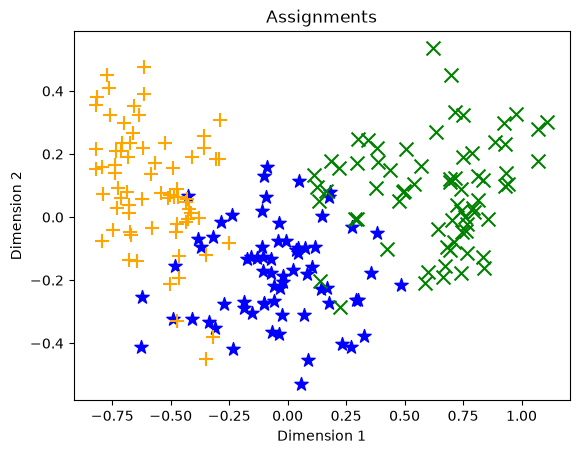

In [8]:
seed_species = data[data.columns[7]]
plot_clusters(features_2d, seed_species.values)

There may be some differences between the cluster assignments and class labels, but the K-Means model should have done a reasonable job of clustering the observations so that seeds of the same species are generally in the same cluster.

<h3 style="font-weight:600;color:white;background:#7fba94;padding:25px;margin:20;text-align:left;display:fill;border-radius:10px 0 0 10px;text-transform:uppercase;">4 | Hierarchical Clustering</h3>

Hierarchical clustering methods make fewer distributional assumptions when compared to K-Means methods. However, K-Means methods are generally more scalable, sometimes very much so.

Hierarchical clustering creates clusters by using either a *divisive* method or an *agglomerative* method. The divisive method is a "top down" approach starting with the entire dataset and then finding partitions in a stepwise manner. Agglomerative clustering is a "bottom up" approach. In this lab you will work with agglomerative clustering which works as follows:

1. The linkage distances between each of the data points are computed.
2. Points are clustered pairwise with their nearest neighbor.
3. Linkage distances between the clusters are computed.
4. Clusters are combined pairwise into larger clusters.
5. Steps 3 and 4 are repeated until all data points are in a single cluster.

The linkage function can be computed in a number of ways:
- *Ward* linkage measures the increase in variance for the clusters being linked.
- *Average* linkage uses the mean pairwise distance between the members of the two clusters.
- *Complete* or *maximal* linkage uses the maximum distance between the members of the two clusters.

Several different distance metrics are used to compute linkage functions:
- *Euclidean* or *l2* distance is the most widely used. This metric is only choice for the Ward linkage method.
- *Manhattan* or *l1* distance is robust to outliers and has other interesting properties.
- *Cosine similarity* is the dot product between the location vectors, divided by the magnitudes of the vectors. Note that this metric is a measure of similarity, whereas the other two metrics are measures of difference. Similarity can be quite useful when working with data such as images or text documents.


<h4 style="font-weight:600;color:white;background:#7fba94;padding:25px;margin:20;text-align:left;display:fill;border-radius:10px 0 0 10px;text-transform:uppercase;">4.1 | Agglomerative Clustering</h4>

Let's see an example of clustering the seeds data using an agglomerative clustering algorithm.

In [9]:
agg_model = AgglomerativeClustering(n_clusters=3)
agg_clusters = agg_model.fit_predict(features.values)

print(agg_clusters)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0
 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 2 0 0 0 1
 0 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 0 2 2 2 2 2 2 0 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 2 0 2 2 2 2 2 2 2 2]


So what do the agglomerative cluster assignments look like?

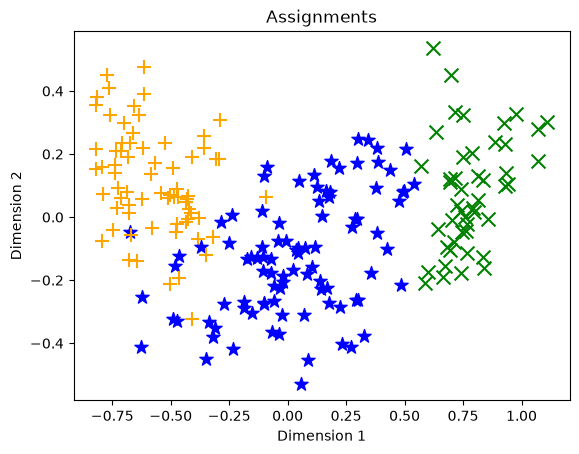

In [10]:
plot_clusters(features_2d, agg_clusters)

|

Let's calculate the Silhouette score.

In [11]:
score = silhouette_score(features.values, agg_clusters)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.422


<h3 style="font-weight:600;color:white;background:#7fba94;padding:25px;margin:20;text-align:left;display:fill;border-radius:10px 0 0 10px;text-transform:uppercase;">5 | Summary</h3>

Here we practiced using K-Means and Hierarchical Clustering. This unsupervised learning, has the ability to take unlabelled data and identify which data points are similar to others.